In [10]:
import h5py
import numpy as np
import matplotlib.pyplot as plt 
import os
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
%matplotlib inline


In [85]:
files = [f for f in os.listdir('signals') if f.find("Cs") > 0]
files = np.sort(files)

signals = []
metadata = []

for i, file in enumerate(files):
    with h5py.File(f"signals/{file}") as f:
        d = dict(f['metadata'].attrs)
        events = np.array(f['waveforms'])
        signals += [events]
        metadata += [d]

dose = [_["dose"] for _ in metadata]
signals = np.array(signals)[np.argsort(dose)]
metadata = np.array(metadata)[np.argsort(dose)]
files = np.array(files)[np.argsort(dose)]
dose = np.sort(dose)

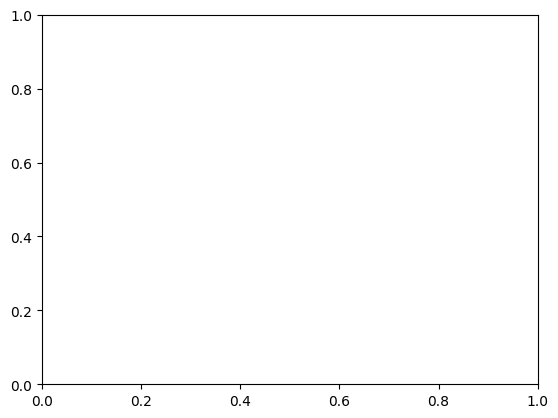

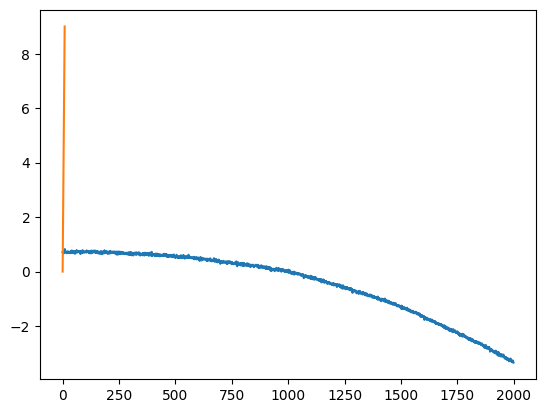

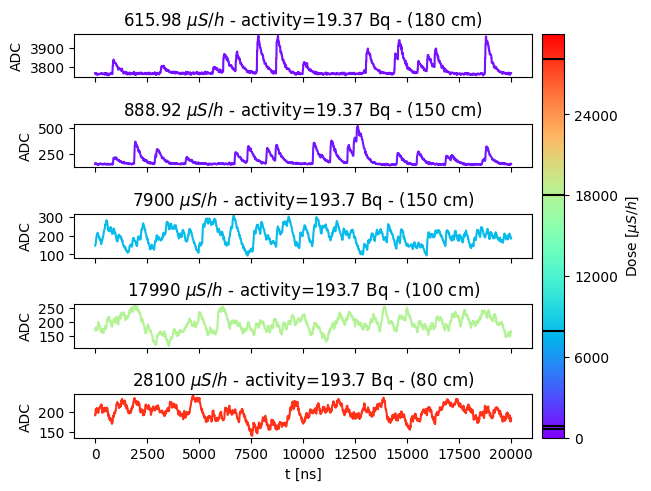

In [12]:
mosaic = np.array([np.arange(5), 5*["c"]]).T
fig,ax = plt.subplot_mosaic(mosaic,constrained_layout=True, sharex=False, width_ratios=[1, 0.05])
cm = plt.cm.rainbow
norm = Normalize(vmin=0, vmax = 30000)
for i in range(len(signals)):
    ax[str(i)].plot(np.arange(len(signals[i][0])).astype(float)*10, signals[i][100], color=cm(norm(metadata[i]['dose'])))
    ax[str(i)].set_title(fr"{metadata[i]['dose']} $\mu S/h$ - activity={metadata[i]['activity']} Bq - ({metadata[i]['distance']} cm)")
    ax[str(i)].set_ylabel("ADC")
    ax['c'].axhline(metadata[i]['dose'], color='k', zorder=100)
    if i < 4:
        ax[str(i)].set_xticklabels([])
    else:
        ax[str(i)].set_xlabel("t [ns]")

ax['c'].set_ylim(0, 30000)
plt.colorbar(ScalarMappable(cmap=cm, norm=norm), cax = ax['c'], label=r"Dose [$\mu S/ h $]")
ax['c'].set_yticks(np.arange(0,5)*30000/5)

fig.savefig("anode_signals.png", dpi=200)

Text(0.5, 0, 'f [Hz]')

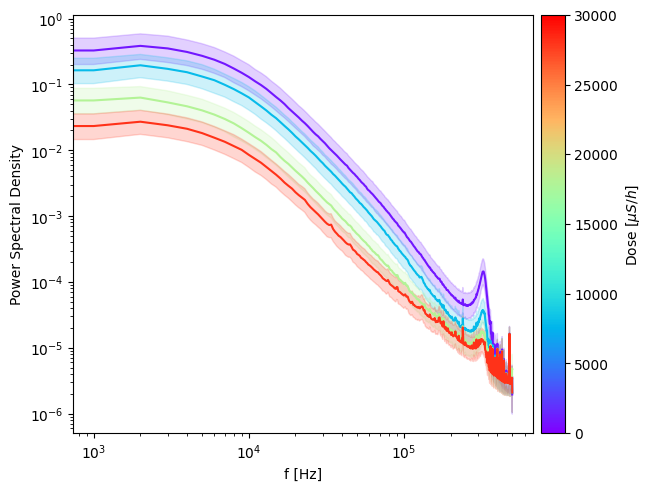

In [97]:
from scipy.signal import welch
fig, ax = plt.subplot_mosaic([["PSD","c"]], width_ratios=[1, 0.05], constrained_layout=True)
for i in range(1, 5):
    f, psd = welch(signals[i], axis=1, fs = 1e6, nperseg=1000, noverlap=500)

    ax["PSD"].plot(f, np.median(psd, axis=0), color=cm(norm(dose[i])))
    ax["PSD"].fill_between(f, *np.quantile(psd, [0.25, 0.75], axis=0), alpha = 0.2, color=cm(norm(dose[i])))
ax["PSD"].set_xscale('log')
ax["PSD"].set_yscale('log')
plt.colorbar(ScalarMappable(cmap=cm, norm=norm), cax = ax['c'], label=r"Dose [$\mu S/ h $]")
ax["PSD"].set_ylabel("Power Spectral Density")
ax['PSD'].set_xlabel("f [Hz]")

AAAAAAAA


Text(0.5, 0, 'f [Hz]')

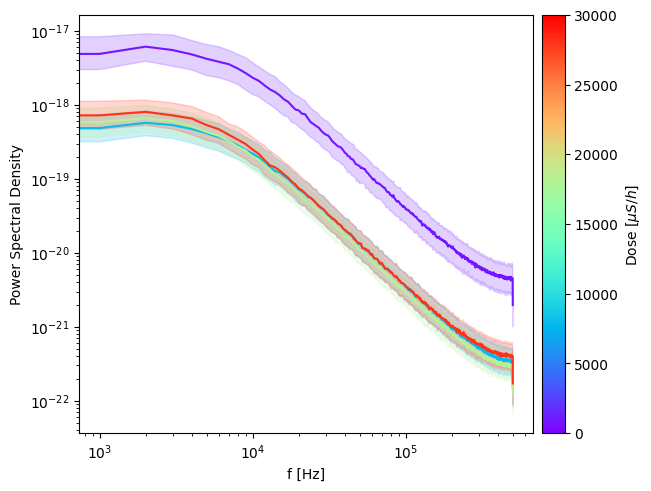

In [104]:
from simulate_pmt import simulate_ou_sde
import json

with open("fit_results.json", "r") as f:
    best_params = json.load(f)

fig, ax = plt.subplot_mosaic([["PSD","c"]], width_ratios=[1, 0.05], constrained_layout=True)
for i, file in enumerate(files):
    if file.find("615")>0:
        print("AAAAAAAA")
        continue
    ffile = f"signals/{file}"
    signals_syn = best_params[ffile]['lam']**(-1)*simulate_ou_sde(lam=best_params[ffile]['lam'], tau_fall=best_params[ffile]['tau_fall'],
                                ser_mean=1, ser_cv=best_params[ffile]['ser_cv'],
                                n_rec=1000, noise_sigma=best_params[ffile]['noise_frac'])
    f, psd = welch(signals_syn, axis=1, fs = 1e6, nperseg=1000, noverlap=500)

    ax["PSD"].plot(f, np.median(psd, axis=0), color=cm(norm(dose[i])))
    ax["PSD"].fill_between(f, *np.quantile(psd, [0.25, 0.75], axis=0), alpha = 0.2, color=cm(norm(dose[i])))
ax["PSD"].set_xscale('log')
ax["PSD"].set_yscale('log')
plt.colorbar(ScalarMappable(cmap=cm, norm=norm), cax = ax['c'], label=r"Dose [$\mu S/ h $]")
ax["PSD"].set_ylabel("Power Spectral Density")
ax['PSD'].set_xlabel("f [Hz]")

In [77]:
with open("fit_results.json", "r") as f:
    a = json.load(f)
a[f"signals/{files[0]}"]

{'lam': 16893697.239975497,
 'tau_rise': 3.366844772056665e-08,
 'tau_fall': 2.5957915947092726e-07,
 'ser_cv': 0.07612791024814908,
 'noise_frac': 0.05950036650520936,
 '_band': {'lam': [10151813.672976946, 17474966.0442459],
  'ser_cv': [0.050064482387546905, 0.17979042294472913],
  'n_near_best': 78,
  'best_obj': 0.4226882493864133}}

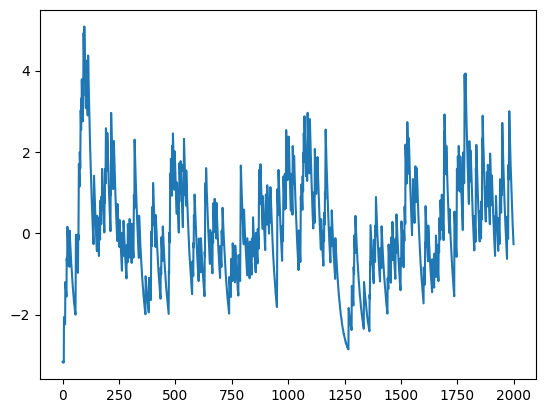

In [103]:
def simulate_ou_shot_noise(lam, tau_fall, DT,
                           n_rec=1000, n_samp=2000,
                           ser_mean=1.0, ser_cv=0.5,
                           noise_sigma=0.0, seed=0):
    """
    Compound Poisson Ornstein-Uhlenbeck process.

    Between events:
        y(t+dt) = y(t) * exp(-dt/tau_fall)

    Each Poisson arrival adds a random charge A_k.

    Parameters
    ----------
    lam : float
        Event rate [Hz]
    tau_fall : float
        Exponential decay time constant [s]
    DT : float
        Sampling interval [s]

    ser_mean : float
        Mean charge per event
    ser_cv : float
        Coefficient of variation of charge distribution
        (gamma distributed amplitudes)

    noise_sigma : float
        Additive Gaussian electronic noise
    """

    rng = np.random.default_rng(seed)

    decay = np.exp(-DT / tau_fall)

    # Poisson number of arrivals per bin
    counts = rng.poisson(
        lam * DT,
        size=(n_rec, n_samp)
    )

    # Random event amplitudes (compound Poisson)
    if ser_cv > 0:
        k = 1.0 / ser_cv**2       # Gamma shape
        theta = ser_mean / k      # Gamma scale

        jumps = np.zeros_like(counts, dtype=float)

        mask = counts > 0

        # Sum of N gamma variables:
        # Gamma(k*N, theta)
        jumps[mask] = rng.gamma(
            shape=k * counts[mask],
            scale=theta
        )

    else:
        jumps = counts.astype(float) * ser_mean


    # OU recursion
    y = np.empty((n_rec, n_samp))

    y[:, 0] = jumps[:, 0]

    for i in range(1, n_samp):
        y[:, i] = decay * y[:, i-1] + jumps[:, i]


    # Additive electronics noise
    if noise_sigma > 0:
        y += rng.normal(
            0,
            noise_sigma,
            size=y.shape
        )

    # AC coupling / baseline removal
    y -= np.median(
        y,
        axis=1,
        keepdims=True
    )

    return y

signals_syn = simulate_ou_shot_noise(14e6, 250e-9, 10e-9,
                                ser_mean=1, ser_cv=0.1,
                                n_rec=1000, noise_sigma=0.01)
plt.plot(signals_syn[1])

(15, 1000)


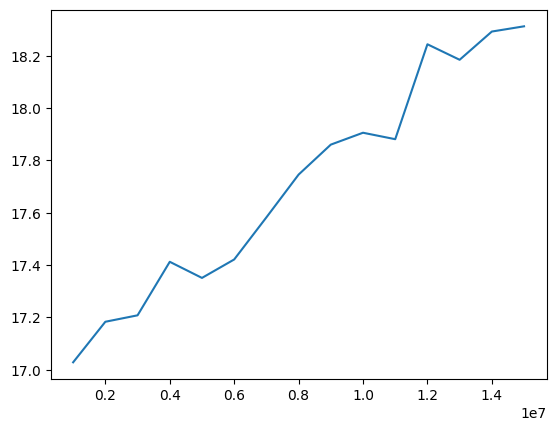

In [117]:
lambdas_samp = np.linspace(1, 15, 15)*1e6
a = []

for lam in lambdas_samp:
    sig = simulate_ou_sde(lam=lam, tau_fall=350e-9,
                        ser_mean=1, ser_cv=0.3,
                        n_rec=1000, noise_sigma=0.02)
    a += [sig.var(axis=-1).mean()/np.mean(np.diff(sig)**2, axis=-1)]
a = np.array(a)
print(a.shape)
plt.plot(lambdas_samp, a.mean(axis=1))